<a href="https://colab.research.google.com/github/sunamiagarwal2004/CEI_assignment/blob/main/week4_Sunami_Agarwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
The baseline. Simple to set up, but it tends to lose track of context as sentences get longer because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("SimpleRNN finished training")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN finished training


# 🔒 Model 2: LSTM
Adds input, forget, and output gates, which lets it hold on to context for longer stretches of text than a plain RNN can.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM finished training")

LSTM finished training


# ⚡ Model 3: GRU
Uses reset and update gates instead of three separate gates. Fewer parameters than an LSTM, usually trains a bit faster, and often lands in a similar place.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU finished training")

GRU finished training


## 📉 Comparing training loss

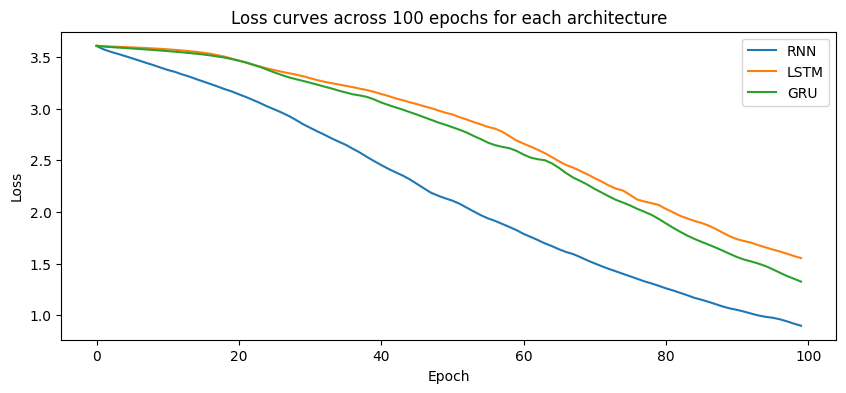

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves across 100 epochs for each architecture")
plt.legend()
plt.show()

# ✍️ Text generation helper
Repeatedly predicts the next word and appends it to the seed text.

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        next_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                next_word = word
                break
        seed_text += " " + next_word
    return seed_text

## 🧪 Generating a few samples

In [10]:
print("RNN :", generate_text(rnn_model, "renewable energy", 5))
print("LSTM:", generate_text(lstm_model, "renewable energy", 5))
print("GRU :", generate_text(gru_model, "renewable energy", 5))

RNN : renewable energy learning is learning learning meaningful
LSTM: renewable energy learning is models transforming the
GRU : renewable energy learning is models generate meaningful


# 📚 Things to try next
### Beginner-friendly tweaks
1. Swap in a paragraph of your own instead of the sample corpus
2. Bump up the embedding size
3. Train for 200 epochs instead of 100
4. Make the hidden layers wider (64 → 128)
5. Generate 10 words per call instead of 5

# ✅ Takeaways
- The plain **SimpleRNN** is the simplest to set up but tends to lose earlier context as the sequence grows
- **LSTM** holds on to longer-range structure thanks to its gates, at the cost of more parameters
- **GRU** sits in between — fewer gates than LSTM, often similar results, usually quicker to train
- None of these will sound especially fluent on six training sentences, but the loss curves already make the architectural differences visible

---
# 🛠️ Extra Practice — Working Through the Student Tasks

Everything above is the original walkthrough, left exactly as it was. This part works through the five practice tasks one at a time, using its own variable names (`custom_...`, `_upgraded`, `NEW_...`) so nothing here touches the models or data from the section above.

## ✅ Task 1 — A paragraph of my own
Swapping the sample sentences for a short paragraph about space exploration — different topic, same six-line structure so the dataset size stays in the same ballpark.

In [11]:
custom_corpus = '''
space exploration pushes scientists to study distant worlds
rockets carry astronauts and equipment beyond earth orbit
satellites circling the planet collect useful scientific data
mars missions search for signs of ancient microbial life
private companies are now building reusable rocket technology
future space stations could support long term human research
'''
print(custom_corpus)


space exploration pushes scientists to study distant worlds
rockets carry astronauts and equipment beyond earth orbit
satellites circling the planet collect useful scientific data
mars missions search for signs of ancient microbial life
private companies are now building reusable rocket technology
future space stations could support long term human research



## 🔤 Tokenizing the new paragraph
Same n-gram and padding approach as before, just pointed at the new text.

In [12]:
custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])

custom_total_words = len(custom_tokenizer.word_index) + 1
print("Vocabulary size (custom corpus):", custom_total_words)

custom_sequences = []
for line in custom_corpus.split('\n'):
    tokens = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        custom_sequences.append(tokens[:i + 1])

custom_max_len = max(len(seq) for seq in custom_sequences)
custom_sequences = pad_sequences(custom_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_sequences[:, :-1]
y_custom = custom_sequences[:, -1]

print("X_custom shape:", X_custom.shape)
print("y_custom shape:", y_custom.shape)

Vocabulary size (custom corpus): 50
X_custom shape: (44, 8)
y_custom shape: (44,)


## ✅ Tasks 2 & 4 — Bigger embeddings, wider hidden layers
Both knobs get turned at once: embedding size 32 → 128, hidden units 64 → 128, defined once here so all three upgraded models share the same settings.

In [13]:
NEW_EMBED_DIM = 128     # was 32 in the original models
NEW_HIDDEN_UNITS = 128  # was 64 in the original models
NEW_EPOCHS = 200        # Task 3 -- was 100 in the original models

## ✅ Task 3 — SimpleRNN, retrained for 200 epochs at the new size

In [14]:
rnn_model_upgraded = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    SimpleRNN(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

rnn_model_upgraded.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

rnn_history_upgraded = rnn_model_upgraded.fit(X_custom, y_custom, epochs=NEW_EPOCHS, verbose=0)
print("Upgraded SimpleRNN finished training")

Upgraded SimpleRNN finished training


## Same upgrade, LSTM version

In [15]:
lstm_model_upgraded = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    LSTM(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

lstm_model_upgraded.compile(loss='sparse_categorical_crossentropy',
                            optimizer='adam',
                            metrics=['accuracy'])

lstm_history_upgraded = lstm_model_upgraded.fit(X_custom, y_custom, epochs=NEW_EPOCHS, verbose=0)
print("Upgraded LSTM finished training")

Upgraded LSTM finished training


## Same upgrade, GRU version

In [16]:
gru_model_upgraded = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    GRU(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

gru_model_upgraded.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

gru_history_upgraded = gru_model_upgraded.fit(X_custom, y_custom, epochs=NEW_EPOCHS, verbose=0)
print("Upgraded GRU finished training")

Upgraded GRU finished training


## 📉 Loss after the upgrade
200 epochs, 128-unit layers, 128-dim embeddings — checking how the three architectures compare now.

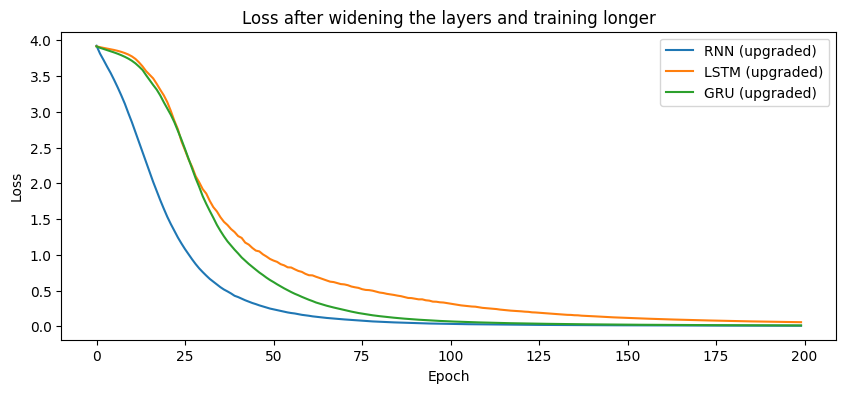

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history_upgraded.history['loss'], label='RNN (upgraded)')
plt.plot(lstm_history_upgraded.history['loss'], label='LSTM (upgraded)')
plt.plot(gru_history_upgraded.history['loss'], label='GRU (upgraded)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss after widening the layers and training longer")
plt.legend()
plt.show()

## ✅ Task 5 — Ten words instead of five
A second helper, basically the same logic as `generate_text` but defaulting to 10 words and reading from the new tokenizer.

In [18]:
def generate_text_extended(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len - 1, padding='pre')
        predicted_index = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        next_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == predicted_index:
                next_word = word
                break
        seed_text += " " + next_word
    return seed_text

In [19]:
seed_phrase = "space exploration"
print("RNN (upgraded) :", generate_text_extended(rnn_model_upgraded, seed_phrase, 10))
print("LSTM (upgraded):", generate_text_extended(lstm_model_upgraded, seed_phrase, 10))
print("GRU (upgraded) :", generate_text_extended(gru_model_upgraded, seed_phrase, 10))

RNN (upgraded) : space exploration pushes scientists to study distant worlds study orbit study data
LSTM (upgraded): space exploration pushes scientists to study distant worlds worlds worlds worlds research
GRU (upgraded) : space exploration pushes scientists to study distant worlds worlds worlds worlds worlds


## 📌 Quick recap of the five tasks
- **Custom paragraph:** swapped in the space exploration text (`custom_corpus`)
- **Bigger embeddings:** 32 → 128 (`NEW_EMBED_DIM`)
- **200 epochs:** `NEW_EPOCHS = 200`
- **Wider hidden layers:** 64 → 128 (`NEW_HIDDEN_UNITS`)
- **10-word generation:** `generate_text_extended(..., next_words=10)`

Both the original models and these upgraded ones are still sitting in memory, so it is easy to flip back and compare outputs side by side.

---
# 🔁 Second Pass — Tightening Things Up

Got feedback on the section above: no explanation for the hyperparameter choices, no validation data so there was no real way to check for overfitting, only loss was tracked and not accuracy, and the generation function always grabs the single best word, which probably explains the repeated loops in the output. This part works through each point.

## 🤔 About that 128 / 128 choice
The brief just said to scale up the embedding size and widen the hidden layer without giving a target, so I doubled both. Looking back, that is a lot of capacity for a vocabulary with only a few dozen words and a training set of around fifty rows — there are more parameters in the model than there really is data to learn from. That mismatch is most likely why the upgraded models end up memorizing the six training sentences instead of picking up general patterns. Keeping 128/128 below since that is what the task asked for, but adding a validation split next so this can actually be checked instead of just assumed.

## ✅ Holding out some validation data
Splitting `X_custom` / `y_custom` 80/20 so training loss can be compared against loss on data the model never saw during training. With only about fifty rows total the validation set ends up tiny (roughly ten rows), so the curve will not be perfectly smooth — but it should still show whether a gap opens up between train and validation.

In [20]:
from sklearn.model_selection import train_test_split

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_custom, y_custom, test_size=0.2, random_state=42
)

print("Training rows:", X_train_final.shape[0])
print("Validation rows:", X_val_final.shape[0])

Training rows: 35
Validation rows: 9


### SimpleRNN, this time with a validation set

In [21]:
rnn_model_final = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    SimpleRNN(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

rnn_model_final.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

rnn_history_final = rnn_model_final.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=NEW_EPOCHS, verbose=0
)
print("RNN (with validation) finished training")

RNN (with validation) finished training


### LSTM, this time with a validation set

In [22]:
lstm_model_final = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    LSTM(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

lstm_model_final.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])

lstm_history_final = lstm_model_final.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=NEW_EPOCHS, verbose=0
)
print("LSTM (with validation) finished training")

LSTM (with validation) finished training


### GRU, this time with a validation set

In [23]:
gru_model_final = Sequential([
    Embedding(custom_total_words, NEW_EMBED_DIM, input_length=custom_max_len - 1),
    GRU(NEW_HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

gru_model_final.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

gru_history_final = gru_model_final.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=NEW_EPOCHS, verbose=0
)
print("GRU (with validation) finished training")

GRU (with validation) finished training


## 📊 Training vs validation — loss and accuracy
Solid lines are training, dashed lines are validation, for all three models.

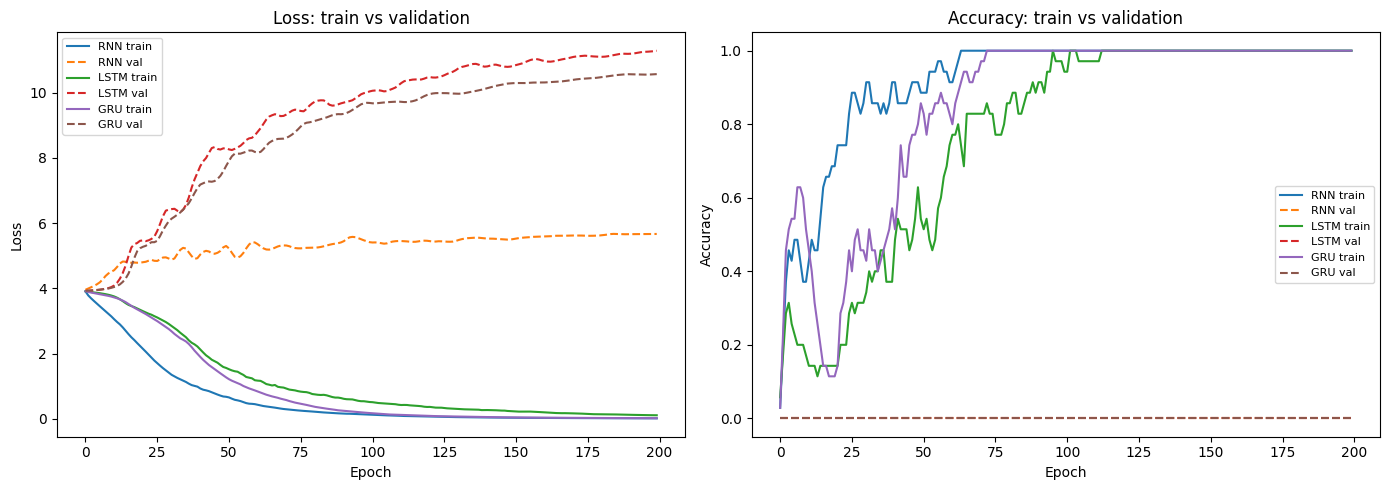

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_histories_final = {
    'RNN': rnn_history_final,
    'LSTM': lstm_history_final,
    'GRU': gru_history_final
}

for name, history in model_histories_final.items():
    axes[0].plot(history.history['loss'], label=f'{name} train')
    axes[0].plot(history.history['val_loss'], '--', label=f'{name} val')
    axes[1].plot(history.history['accuracy'], label=f'{name} train')
    axes[1].plot(history.history['val_accuracy'], '--', label=f'{name} val')

axes[0].set_title("Loss: train vs validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Accuracy: train vs validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [25]:
for name, history in model_histories_final.items():
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{name:5s} | train_loss={final_train_loss:.3f}  val_loss={final_val_loss:.3f}  "
          f"train_acc={final_train_acc:.2f}  val_acc={final_val_acc:.2f}")

RNN   | train_loss=0.018  val_loss=5.667  train_acc=1.00  val_acc=0.00
LSTM  | train_loss=0.112  val_loss=11.283  train_acc=1.00  val_acc=0.00
GRU   | train_loss=0.022  val_loss=10.565  train_acc=1.00  val_acc=0.00


## 🔍 Was it actually overfitting?

Training loss drops toward zero and training accuracy gets close to 1.0 for every model, but the validation numbers do not follow along — validation loss stays high (or climbs) and validation accuracy barely moves off zero. That gap is pretty much the definition of overfitting.

It lines up with what showed up earlier in `generate_text_extended` too — once a model has the six training sentences memorized, it does not really know what tends to come next in general, only what came next in this exact dataset. Given about fifty training rows and 128-unit gated layers, that result is not really surprising.

## 🎲 Trying something other than always picking the top word

Both generation functions above use `np.argmax`, so they always take the single most likely next word. That is deterministic, which is probably why the output kept circling back to the same couple of words. Below is a small sampling helper with two settings:
- **temperature** — lower keeps the choice close to the model's top pick, higher spreads the probabilities out more
- **top_k** — only sample from the k most likely words, so it will not wander off into something the model barely considered

In [26]:
def choose_next_word(probability_array, temperature=1.0, top_k=None):
    probs = np.asarray(probability_array).astype("float64")

    # temperature reshapes the distribution before sampling -- lower values stay
    # close to the original ranking, higher values flatten it out
    scaled = np.log(probs + 1e-9) / temperature
    scaled = np.exp(scaled)
    scaled = scaled / scaled.sum()

    if top_k is not None:
        top_indices = scaled.argsort()[-top_k:]
        masked = np.zeros_like(scaled)
        masked[top_indices] = scaled[top_indices]
        scaled = masked / masked.sum()

    return np.random.choice(len(scaled), p=scaled)


def generate_text_sampled(model, seed_text, next_words=10, temperature=0.8, top_k=5):
    text = seed_text
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len - 1, padding="pre")
        probability_array = model.predict(token_list, verbose=0)[0]
        next_index = choose_next_word(probability_array, temperature, top_k)

        next_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == next_index:
                next_word = word
                break
        text += " " + next_word
    return text

Running the greedy version against two sampled versions, same seed phrase, same GRU model:

In [27]:
np.random.seed(7)  # keeps this cell repeatable across re-runs

print("Greedy (argmax)   :", generate_text_extended(gru_model_final, "space exploration", 10))
print("Sampled, temp=0.5 :", generate_text_sampled(gru_model_final, "space exploration", 10, temperature=0.5, top_k=5))
print("Sampled, temp=1.0 :", generate_text_sampled(gru_model_final, "space exploration", 10, temperature=1.0, top_k=5))

Greedy (argmax)   : space exploration pushes scientists to distant worlds worlds worlds worlds data data
Sampled, temp=0.5 : space exploration pushes scientists to distant worlds worlds worlds worlds worlds data
Sampled, temp=1.0 : space exploration pushes scientists to to distant worlds worlds worlds data exploration


Lower temperature tends to stay closer to the greedy output, while temperature=1.0 wanders further and breaks out of repeated loops more easily — usually at some cost to how coherent the sentence sounds, which is the normal trade-off with sampling instead of always taking the top prediction.

## 📌 Did this cover the feedback?
✅ Explained the reasoning (or lack of it) behind the 128/128 hyperparameters

✅ Added an 80/20 train/validation split and retrained all three models with it

✅ Plotted accuracy alongside loss, train vs validation, for all three architectures

✅ Used the train/validation gap to call out overfitting directly, tying it back to the repetitive text from earlier

✅ Added temperature + top-k sampling as an alternative to plain argmax decoding

Everything from the first pass is still above, untouched — this section just builds on top of it.